<a href="https://colab.research.google.com/github/phantrang184/Data-analysis-in-business-lecture-assignment/blob/main/3_Khai_ph%C3%A1_d%E1%BB%AF_li%E1%BB%87u.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PTDL/Train.csv')

In [ ]:
df

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [ ]:
df = pd.get_dummies(df, drop_first = True, dtype=int)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

In [ ]:
X = df.drop(columns=['Reached.on.Time_Y.N'])  # bỏ biến mục tiêu
X = add_constant(X)

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                      feature        VIF
0                       const  83.072636
1                          ID   1.673627
2         Customer_care_calls   1.282990
3             Customer_rating   1.000696
4         Cost_of_the_Product   1.160988
5             Prior_purchases   1.090715
6            Discount_offered   1.722347
7               Weight_in_gms   1.439082
8           Warehouse_block_B   1.668697
9           Warehouse_block_C   1.667642
10          Warehouse_block_D   1.667707
11          Warehouse_block_F   2.001625
12      Mode_of_Shipment_Road   1.673021
13      Mode_of_Shipment_Ship   1.673751
14     Product_importance_low   3.485324
15  Product_importance_medium   3.448309
16                   Gender_M   1.001303


In [ ]:
df.isnull().sum()

,0
ID,0
Customer_care_calls,0
Customer_rating,0
Cost_of_the_Product,0
Prior_purchases,0
Discount_offered,0
Weight_in_gms,0
Reached.on.Time_Y.N,0
Warehouse_block_B,0
Warehouse_block_C,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
ID,int64
Customer_care_calls,int64
Customer_rating,int64
Cost_of_the_Product,int64
Prior_purchases,int64
Discount_offered,int64
Weight_in_gms,int64
Reached.on.Time_Y.N,int64
Warehouse_block_B,int64
Warehouse_block_C,int64


<Axes: >

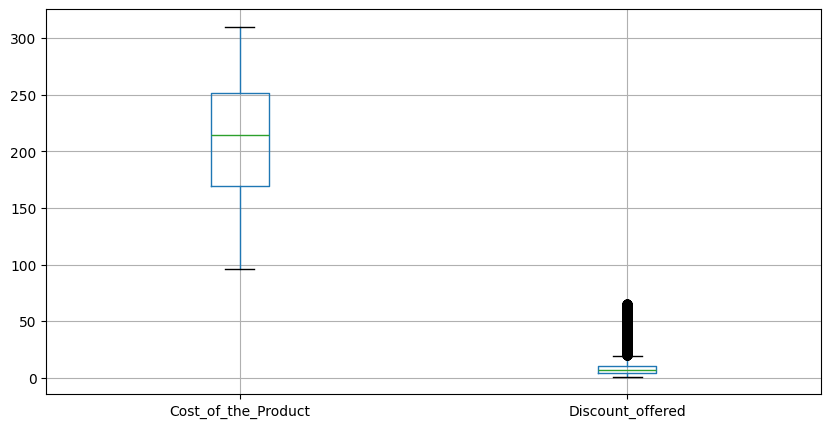

In [ ]:
df.describe()
df.boxplot(column=['Cost_of_the_Product', 'Discount_offered'], figsize=(10, 5))

In [ ]:
# chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Mô hình K-Mean Clustering

In [ ]:
df

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,1,4,2,177,3,44,1233,1,0,0,1,0,0,0,1,0,0
1,2,4,5,216,2,59,3088,1,0,0,0,1,0,0,1,0,1
2,3,2,2,183,4,48,3374,1,0,0,0,0,0,0,1,0,1
3,4,3,3,176,4,10,1177,1,1,0,0,0,0,0,0,1,1
4,5,2,2,184,3,46,2484,1,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,4,1,252,5,1,1538,1,0,0,0,0,0,1,0,1,0
10995,10996,4,1,232,5,6,1247,0,1,0,0,0,0,1,0,1,0
10996,10997,5,4,242,5,4,1155,0,0,1,0,0,0,1,1,0,0
10997,10998,5,2,223,6,2,1210,0,0,0,0,1,0,1,0,1,1


In [ ]:
# Chuẩn bị dữ liệu
x = df.drop('Reached.on.Time_Y.N', axis=1)
y = df['Reached.on.Time_Y.N']

In [ ]:
# Chia dữ liệu thành 2 phần 80-20
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=101)

In [ ]:
# 1, Tạo biến
error = []
k_value = range(1,40) # k sẽ chạy từ 1 đến 39
for k in k_value:
  #gọi mô hình
  kmeans = KMeans(n_clusters=k)
  #train mô hình
  kmeans.fit(x_train)
  #dự đoán, tìm y-pred
  y_pred = kmeans.predict(x_test)
  #đánh giá mô hình thông qua error
  err = np.mean(y_pred != y_test)
  # 3, đưa data và biến đã tạo
  error.append(err)

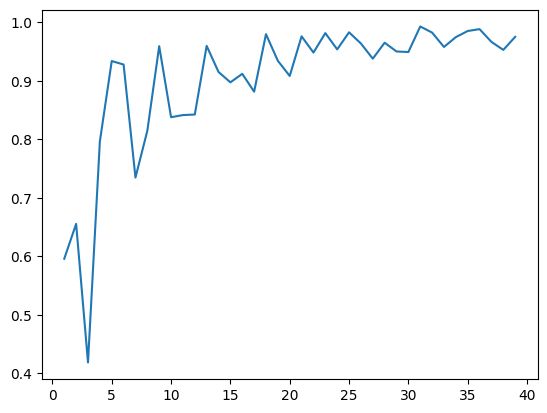

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(1,40),error)

Vì biến phụ thuộc là biến nhị phân

In [ ]:
# Gọi mô hình K-Mean Clustering
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2)

In [ ]:
# Train mô hình
kmeans.fit(x_train)

KMeans(n_clusters=2)

In [ ]:
# Dự đoán trên X-test để tìm y_pred
y_pred = kmeans.predict(x_test)
y_pred

array([1, 0, 0, ..., 0, 1, 1], dtype=int32)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[627 262]
 [494 817]]
              precision    recall  f1-score   support

           0       0.56      0.71      0.62       889
           1       0.76      0.62      0.68      1311

    accuracy                           0.66      2200
   macro avg       0.66      0.66      0.65      2200
weighted avg       0.68      0.66      0.66      2200



AUC Score: 0.6642376224711042


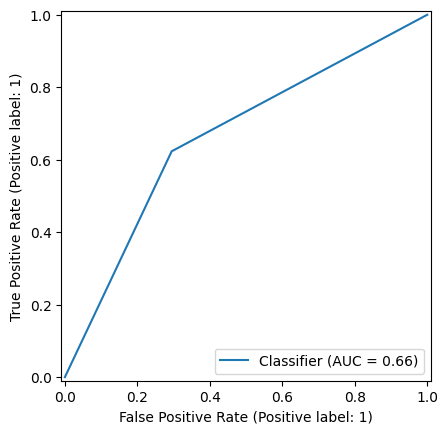

In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred)
print("AUC Score:", roc_auc)

RocCurveDisplay.from_predictions(y_test, y_pred)

Nhận xét:
- Vì biến phụ thuộc là biến nhị phân nên cần 2 clusters nhưng trong đó khi xét tìm số nhóm phù hợp nhất cho mô hình thì 1 là số tốt nhất. Vì thế đảm bảo tính chính xác của mô hình, nhóm lựa chọn 2 clusters và kết quả nhận được accuracy theo f1-score là 0.66 với với AUC tương ứng.
- Kết quả trên cho thấy mô hình này có mức dự báo không quá cao


# Mô hình KNN

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=101)

In [ ]:
error = []
from sklearn.neighbors import KNeighborsClassifier
k_value = range(1,40)
for k in k_value:
  kNN= KNeighborsClassifier(n_neighbors=k)
  kNN.fit(x_train, y_train)
  y_pred = kNN.predict(x_test)
  err = np.mean(y_pred != y_test)
  error.append(err)

In [ ]:
error

[np.float64(0.33954545454545454),
 np.float64(0.31227272727272726),
 np.float64(0.3372727272727273),
 np.float64(0.32272727272727275),
 np.float64(0.32954545454545453),
 np.float64(0.3259090909090909),
 np.float64(0.3377272727272727),
 np.float64(0.3231818181818182),
 np.float64(0.32954545454545453),
 np.float64(0.32727272727272727),
 np.float64(0.33136363636363636),
 np.float64(0.32045454545454544),
 np.float64(0.32727272727272727),
 np.float64(0.32545454545454544),
 np.float64(0.3331818181818182),
 np.float64(0.3331818181818182),
 np.float64(0.33045454545454545),
 np.float64(0.32681818181818184),
 np.float64(0.33045454545454545),
 np.float64(0.3236363636363636),
 np.float64(0.3281818181818182),
 np.float64(0.3286363636363636),
 np.float64(0.3390909090909091),
 np.float64(0.3231818181818182),
 np.float64(0.3281818181818182),
 np.float64(0.32227272727272727),
 np.float64(0.3281818181818182),
 np.float64(0.32727272727272727),
 np.float64(0.3368181818181818),
 np.float64(0.33318181818181

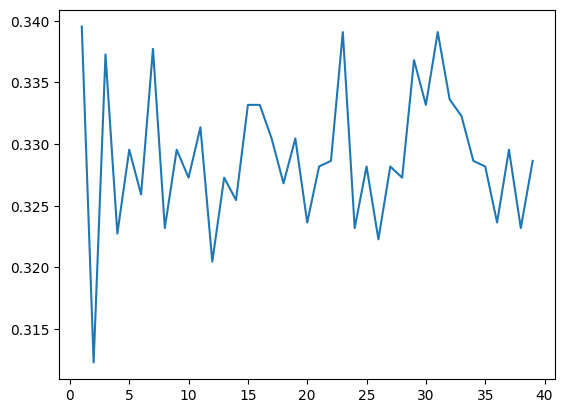

In [ ]:
plt.plot(range(1,40), error)

Vậy k=2 là phù hợp nhất (error thấp nhất)

In [ ]:
kNN= KNeighborsClassifier(n_neighbors=2)
kNN.fit(x_train, y_train)
y_pred = kNN.predict(x_test)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[742 147]
 [540 771]]
              precision    recall  f1-score   support

           0       0.58      0.83      0.68       889
           1       0.84      0.59      0.69      1311

    accuracy                           0.69      2200
   macro avg       0.71      0.71      0.69      2200
weighted avg       0.73      0.69      0.69      2200



AUC Score: 0.7113731778950972


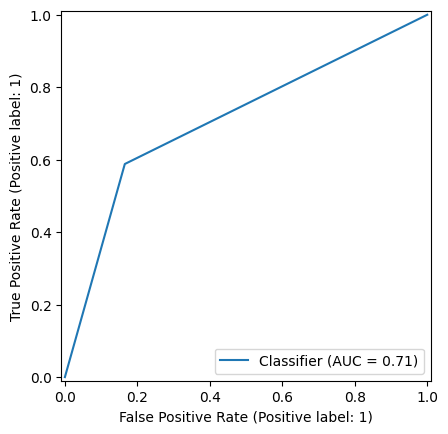

In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred)
print("AUC Score:", roc_auc)

RocCurveDisplay.from_predictions(y_test, y_pred)

**Nhận xét kết quả mô hình K-Nearest Neighbors (K-NN)**

Sau khi thực hiện huấn luyện mô hình K-Nearest Neighbors (K-NN) với tập dữ liệu E-Commerce Shipping, mô hình được tối ưu với giá trị **k = 2**, do tại giá trị này mô hình cho **tỷ lệ lỗi thấp nhất (~31.5%)** so với các giá trị k từ 1 đến 39.

Khi đánh giá mô hình với k = 2 trên tập test, kết quả cho thấy:

**Độ chính xác (Accuracy):** 69% – đây là mức trung bình, phản ánh mô hình dự đoán đúng khoảng 7/10 trường hợp.

**F1-score trung bình (macro avg):** 0.69 – cho thấy sự cân bằng giữa precision và recall cho cả hai lớp.

**Precision & Recall:**
*   Lớp 1 (Reached on time): precision = 0.84, recall = 0.59
*   Lớp 0 (Not reached on time): precision = 0.58, recall = 0.83

Điều này cho thấy mô hình **dự đoán đúng các đơn hàng không giao đúng hạn khá tốt (recall = 83%)**, nhưng lại **bỏ sót nhiều đơn hàng giao đúng hạn (recall = 59%)**.

Ngoài ra, chỉ số **AUC (Area Under Curve) đạt 0.71**, thể hiện **mức độ phân biệt giữa hai lớp là tương đối tốt**. Đường cong ROC nằm trên đường chéo (baseline), chứng tỏ mô hình có năng lực phân loại tốt hơn mô hình ngẫu nhiên.

**Kết luận:**

Mô hình K-NN với k = 2 hoạt động khá ổn trong việc phân loại các đơn hàng có giao đúng hạn hay không.

Tuy nhiên, mô hình vẫn **thiên lệch** một chút khi ưu tiên phát hiện các đơn hàng giao trễ, dẫn đến recall thấp cho lớp "đúng hạn".

Nếu mục tiêu của doanh nghiệp là **phòng ngừa các đơn hàng trễ**, mô hình này có thể hữu ích. Tuy nhiên, để tăng hiệu quả, nên thử nghiệm thêm với các kỹ thuật chọn đặc trưng, chuẩn hóa dữ liệu hoặc thử các mô hình khác như Random Forest hay Logistic Regression để so sánh hiệu suất.

# Mô hình XGboost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=101)

In [ ]:
model = XGBClassifier(eval_metric='logloss', random_state=101)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=101, ...)

In [ ]:
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.64      0.61       889
           1       0.74      0.67      0.70      1311

    accuracy                           0.66      2200
   macro avg       0.65      0.66      0.65      2200
weighted avg       0.67      0.66      0.66      2200

Confusion Matrix:
[[573 316]
 [429 882]]


AUC Score: 0.6586566553322711


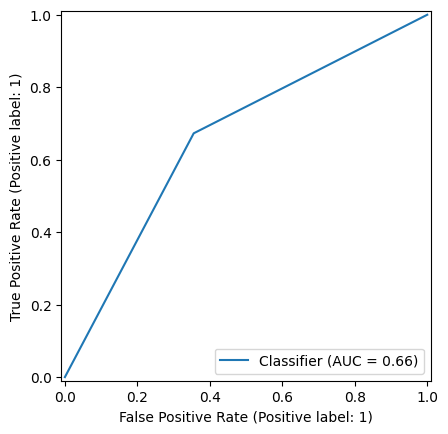

In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred)
print("AUC Score:", roc_auc)

RocCurveDisplay.from_predictions(y_test, y_pred)

**Nhận xét**

Độ chính xác (accuracy) thấp hơn một chút, khoảng **66%**.

Precision class 1: **0.74**, recall: **0.67**, f1-score: **0.70** — cho thấy mô hình cân bằng hơn giữa precision và recall so với KNN.

Chỉ số **AUC = 0.66**, thấp hơn mô hình KNN, phản ánh khả năng phân biệt hai lớp yếu hơn.

**KNN (k=2)** cho kết quả tốt hơn về **độ chính xác tổng thể (accuracy)** và **khả năng phân biệt giữa hai lớp (AUC)**.

Trong khi đó, **XGBoost** tỏ ra hiệu quả hơn ở mặt **cân bằng giữa precision và recall**, đặc biệt là với lớp giao đúng hạn.

Tùy vào mục tiêu nghiệp vụ, nếu ưu tiên **phân biệt tốt giữa các trường hợp**, KNN có thể được ưu tiên. Nếu yêu cầu mô hình **ổn định và cân bằng hơn**, XGBoost sẽ là lựa chọn phù hợp hơn.

# Mô hình Random forest

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=101)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(x_train, y_train)
y_pred=rf.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 1, 0])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.73      0.64       889
           1       0.78      0.62      0.69      1311

    accuracy                           0.67      2200
   macro avg       0.67      0.68      0.67      2200
weighted avg       0.69      0.67      0.67      2200



AUC Score: 0.6780980180681075


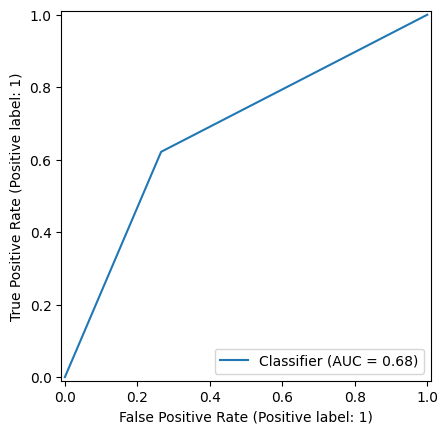

In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred)
print("AUC Score:", roc_auc)

RocCurveDisplay.from_predictions(y_test, y_pred)

Accuracy = 67%
Mức độ chính xác tương đối tốt cho bài toán phân loại nhị phân trên dữ liệu thực tế có nhiều nhiễu.

Tuy nhiên, vẫn có thể cải thiện qua việc tối ưu tham số hoặc xử lý mất cân bằng dữ liệu (nếu có).

Precision class 1 = 0.78
Nghĩa là: trong tất cả các đơn hệ thống dự đoán là giao trễ, có 78% là đúng.

Điều này rất quan trọng trong quản lý rủi ro, vì doanh nghiệp muốn tránh dự đoán sai đơn trễ → không chuẩn bị ứng phó.

Recall class 0 = 0.73
Mô hình có khả năng nhận diện khá tốt các đơn hàng giao đúng hạn.

Tuy nhiên, Recall class 1 = 0.62 lại cho thấy mô hình bỏ sót khoảng 38% đơn giao trễ – có thể ảnh hưởng đến trải nghiệm khách hàng nếu dùng để dự báo thực tế.
F1-score ~ 0.64 – 0.69
Mức trung bình khá, cân bằng giữa Precision và Recall.

Mô hình phù hợp nếu doanh nghiệp không muốn đánh đổi quá nhiều giữa việc phát hiện nhầm và bỏ sót.


# Mô hình Logistics Regression


--- Kết quả đánh giá mô hình Logistic Regression ---
              precision    recall  f1-score   support

           0       0.56      0.61      0.59       889
           1       0.72      0.68      0.70      1311

    accuracy                           0.65      2200
   macro avg       0.64      0.65      0.64      2200
weighted avg       0.66      0.65      0.65      2200

Độ chính xác của mô hình Logistic Regression: 0.6513636363636364

Ma trận nhầm lẫn cho mô hình Logistic Regression:
[[544 345]
 [422 889]]

AUC của mô hình Logistic Regression: 0.7340


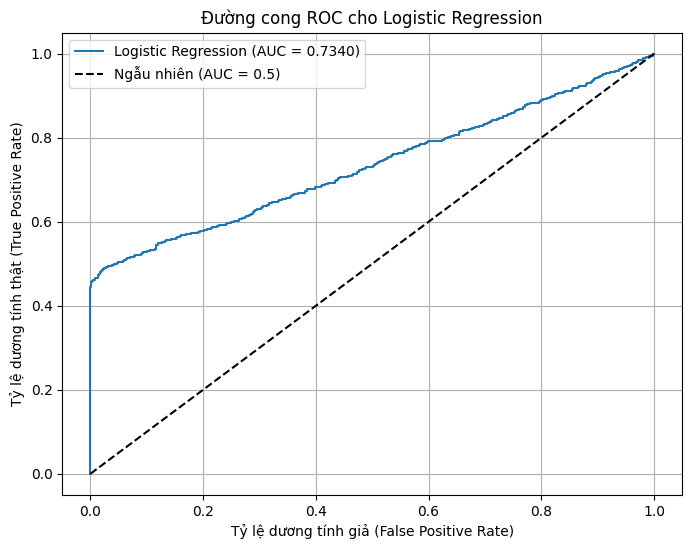

In [ ]:
# prompt: Khai phá logistics regression và tự đánh giá

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

log_reg = LogisticRegression(solver='liblinear', random_state=101)

# Huấn luyện mô hình Logistic Regression
log_reg.fit(x_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred_logreg = log_reg.predict(x_test)

# Dự đoán xác suất cho lớp dương (lớp 1 - Reached.on.Time_Y.N = 1)
y_prob_logreg = log_reg.predict_proba(x_test)[:, 1]

# Đánh giá mô hình Logistic Regression
print("\n--- Kết quả đánh giá mô hình Logistic Regression ---")
print(classification_report(y_test, y_pred_logreg))
print("Độ chính xác của mô hình Logistic Regression:", accuracy_score(y_test, y_pred_logreg))
print("\nMa trận nhầm lẫn cho mô hình Logistic Regression:")
print(confusion_matrix(y_test, y_pred_logreg))

# Tính và in ra AUC
auc_logreg = roc_auc_score(y_test, y_prob_logreg)
print(f"\nAUC của mô hình Logistic Regression: {auc_logreg:.4f}")

# Vẽ đường cong ROC (tùy chọn)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logreg)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_logreg:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên (AUC = 0.5)')
plt.xlabel('Tỷ lệ dương tính giả (False Positive Rate)')
plt.ylabel('Tỷ lệ dương tính thật (True Positive Rate)')
plt.title('Đường cong ROC cho Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

**Nhận xét:**
Khai phá logistics regression có precision, recall, f1 score khá thấp.Trong đó, precision chỉ dao động tầm từ 50%-70%. Với ma trận nhầm lẫn (confusion matrix), mô hình đang nghiên về vận chuyển đúng giờ.
Mô hình ROC là một mô hình khá ổn, khoảng 0,7225. Mức này cho thấy khả năng phân biệt tốt hơn mức ngẫu nhiên và có mang lại giá trị dự đoán.

## Sơ kết:
- Dựa vào chỉ số accuracy (f1-score) thì mô hình KNN có chỉ số cao nhất trong 4 mô hình với 69%. Đồng thời chỉ số AUC mô hình này khá cao bằng 0.71. Tuy nhiên, mô hình vẫn thiên lệch khi ưu tiên phát hiện các đơn hàng giao trễ
- Mô hình XGBoost thì kết quả thu được cân bằng cho cả hai bên dự báo với mức chính xác là 66%. Vì thế nhóm sẽ dự báo tổng dữ liệu để xác định chính xác

# 2. Dự báo bằng mô hình KNN và XGBoost

In [ ]:
#Mô hình XGBoost

model = XGBClassifier(eval_metric='logloss', random_state=101)
model.fit(x, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=101, ...)

In [ ]:
y_pred = model.predict(x)

print("Classification Report:")
print(classification_report(y, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.91      4436
           1       0.97      0.90      0.93      6563

    accuracy                           0.92     10999
   macro avg       0.91      0.93      0.92     10999
weighted avg       0.92      0.92      0.92     10999



/tmp/ipython-input-165-613127758.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentages.index, y=percentages.values, palette="viridis")


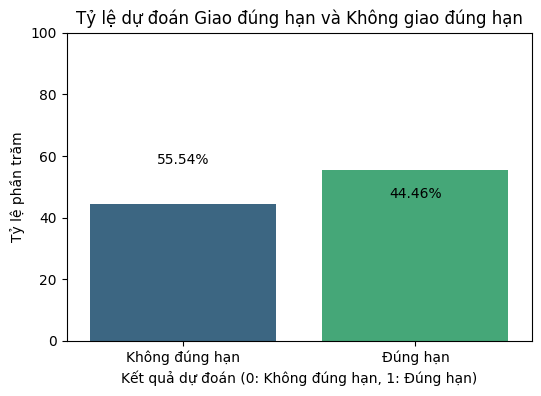

In [ ]:
# Calculate the percentage of 0s and 1s in y_pred_all
percentages = (pd.Series(y_pred).value_counts(normalize=True) * 100)

# Create the bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x=percentages.index, y=percentages.values, palette="viridis")
plt.title('Tỷ lệ dự đoán Giao đúng hạn và Không giao đúng hạn')
plt.xlabel('Kết quả dự đoán (0: Không đúng hạn, 1: Đúng hạn)')
plt.ylabel('Tỷ lệ phần trăm')
plt.xticks([0, 1], ['Không đúng hạn', 'Đúng hạn'])
plt.ylim(0, 100) # Ensure y-axis is from 0 to 100

# Add percentage labels on top of bars
for i, percentage in enumerate(percentages.values):
    plt.text(i, percentage + 2, f'{percentage:.2f}%', ha='center')

plt.show()

In [ ]:
# Mô hình KNN

# Sử dụng toàn bộ dữ liệu để huấn luyện KNN và dự đoán
knn = KNeighborsClassifier(n_neighbors=2) # Chọn số hàng xóm (ví dụ là 5)
knn.fit(x, y)

# Dự đoán trên toàn bộ dữ liệu
y_pred_all = knn.predict(x)

# In ra kết quả dự đoán
print("Kết quả dự đoán trên toàn bộ dữ liệu:")
print(y_pred_all)

# Đánh giá hiệu suất trên toàn bộ dữ liệu (không khuyến khích trong thực tế vì dễ overfitting)
print("\nBáo cáo phân loại trên toàn bộ dữ liệu:")
print(classification_report(y, y_pred_all))

Kết quả dự đoán trên toàn bộ dữ liệu:
[1 1 1 ... 0 0 0]

Báo cáo phân loại trên toàn bộ dữ liệu:
              precision    recall  f1-score   support

           0       0.70      1.00      0.82      4436
           1       1.00      0.71      0.83      6563

    accuracy                           0.83     10999
   macro avg       0.85      0.86      0.83     10999
weighted avg       0.88      0.83      0.83     10999



/tmp/ipython-input-161-2096469591.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentages.index, y=percentages.values, palette="viridis")


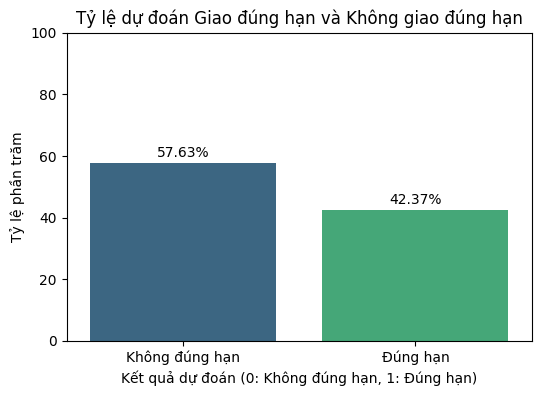

In [ ]:
# Calculate the percentage of 0s and 1s in y_pred_all
percentages = (pd.Series(y_pred_all).value_counts(normalize=True) * 100)

# Create the bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x=percentages.index, y=percentages.values, palette="viridis")
plt.title('Tỷ lệ dự đoán Giao đúng hạn và Không giao đúng hạn')
plt.xlabel('Kết quả dự đoán (0: Không đúng hạn, 1: Đúng hạn)')
plt.ylabel('Tỷ lệ phần trăm')
plt.xticks([0, 1], ['Không đúng hạn', 'Đúng hạn'])
plt.ylim(0, 100) # Ensure y-axis is from 0 to 100

# Add percentage labels on top of bars
for i, percentage in enumerate(percentages.values):
    plt.text(i, percentage + 2, f'{percentage:.2f}%', ha='center')

plt.show()

**Nhận xét: **
- Từ hai biểu đồ về kết quả dự đoán hàng giao đúng hạn và không giao đúng hạn, mô hình XGBoost có sự dự đoán đồng đều giữa hai mặt hơn. Để đạt hiệu quả cho cả hai bên dự đoán thì mô hình XGBoost phù hợp hơn dù tính chính xác thấp hơn mô hình KNN nhưng không đáng kể.
- Biểu đồ của mô hình XGBoost có phân phối dự đoán cân bằng hơn, thể hiện khả năng phân biệt giữa đúng hạn và không đúng hạn tốt hơn. Do đó, nên chọn mô hình mô hình XGBoost.

# Tổng kết

Nguyên nhân của việc vận chuyển không đúng hạn:
- Người bán hàng, người vận chuyển, kho hàng, người nhận
- Phương thức vận chuyển bằng tàu ship có tỷ lệ vận chuyển đúng giờ cao nhất trong ba loại. Nên cần xem xét hình thức vận chuyển còn lại và phân loại các hàng hóa phù hợp từng phương thức để đạt mức giao hàng chính xác nhất
Giải pháp cho việc vận chuyển đúng giờ:
- Kho hàng: lượng vận chuyển đúng hạn bằng nhau với 60% tức là trong dài hạn, doanh nghiệp có thể xem xét bỏ bớt và đổi vị trí kho hàng để nâng mức giao hàng đúng hạn lên 80%
- Đổi phương thức sản phẩm: Phân loại hàng hóa cho từng phương thức (hàng hóa dễ hư hỏng, hàng hóa cần giao nhanh, hàng hóa ở xa...)
- Phổ cập cho của nhân viên, có thể áp dụng "carrot và stick" để nâng cao hiệu suất giao hàng. Việc này có thể sẽ hiệu quả trong trường hợp nhân viên chủ quan do giá trị đơn hàng thấp.
- Đặt một chỉ tiêu cao hơn đối với các đối tác như warehouse hay shipment và cần cân nhắc sàng lọc đối tác trước khi chính thức hợp tác. Đồng thời đảm bảo các điều khoản rõ ràng về mức độ cung cấp dịch vụ. Điều này có thể thúc đẩy tiến độ công việc và sự chuyên tâm vào công việc.
- Sắp xếp, phân chia đơn hàng theo cân nặng của đơn hàng một cách hợp lý để tối ưu hóa thời gian vận chuyển.
- Khách hàng thân thiết nên có quy trình ưu tiên xử lý.
- Cá nhân hóa dịch vụ giao hàng.